# TRABAJO FINAL UT7 - AGRUPACIÓN

Para este trabajo he buscado datasets variados intentando que fueran interesantes.

Los 3 datasets que uso son:

**1. Exoplanetas** → para Clustering y métricas
- Descargado de: https://github.com/OpenExoplanetCatalogue/oec_tables
- Son más de 5000 exoplanetas confirmados con sus propiedades (masa, radio, período orbital, temperatura, distancia...)
- La idea es agruparlos por tipo de planeta (rocosos, gigantes gaseosos, Júpiteres calientes...)

**2. Transacciones de panadería** → para Market Basket (Apriori)
- Descargado de: https://github.com/viktree/curly-octo-chainsaw/blob/master/BreadBasket_DMS.csv
- Unas 21000 líneas de una panadería real con 9500 transacciones y 95 productos diferentes

**3. NSL-KDD (Ciberseguridad)** → para Detección de Anomalías
- Descargado de: https://github.com/jmnwong/NSL-KDD-Dataset
- 125973 conexiones de red registradas: 67343 normales y 58630 ataques/intrusiones (46.5%)
- Contiene 23 tipos de ataque distintos (neptune, satan, smurf, portsweep...)
- Es uno de los datasets de referencia en ciberseguridad para detección de intrusos

---
## 1. EDA

### 1.1 Preprocesado de los datos

Trabajo con el dataset de **exoplanetas** para toda la parte de clustering.

### Importar dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
# Cargo el dataset de exoplanetas
dataset = pd.read_csv('exoplanetas.csv')
dataset.head(10)

,name,binaryflag,mass,radius,period,semimajoraxis,eccentricity,periastron,longitude,ascendingnode,...,lastupdate,system_rightascension,system_declination,system_distance,hoststar_mass,hoststar_radius,hoststar_metallicity,hoststar_temperature,hoststar_age,list
0,Kepler-1032 b,0,NaN,0.167,3.290118,NaN,NaN,NaN,NaN,NaN,...,16/05/10,19 19 43.4040,+40 05 51.8400,683.854,0.770,0.710,0.16,4647.0,NaN,Confirmed planets
1,HD 154857 b,0,2.24000,NaN,408.600000,1.291,0.46,57.0,NaN,NaN,...,14/01/25,17 11 15.7217,-56 40 50.8706,64.200,1.718,2.310,-0.31,5508.0,NaN,Confirmed planets
2,HD 154857 c,0,2.58000,NaN,3452.000000,5.360,0.06,352.0,NaN,NaN,...,14/01/25,17 11 15.7217,-56 40 50.8706,64.200,1.718,2.310,-0.31,5508.0,NaN,Confirmed planets
3,Kepler-994 b,0,NaN,0.143,1.151167,NaN,NaN,NaN,NaN,NaN,...,16/05/10,19 16 17.3254,+47 24 25.3965,189.186,0.560,0.540,-0.13,3934.0,NaN,Confirmed planets
4,Kepler-1350 b,0,NaN,0.225,4.496860,NaN,NaN,NaN,NaN,NaN,...,16/05/10,19 13 00.1410,+46 40 46.5233,343.926,0.550,0.530,-0.06,3827.0,NaN,Confirmed planets
5,Kepler-1350 c,0,NaN,0.154,1.766789,NaN,NaN,NaN,NaN,NaN,...,16/05/10,19 13 00.1410,+46 40 46.5233,343.926,0.550,0.530,-0.06,3827.0,NaN,Confirmed planets
6,Kepler-1268 b,0,NaN,0.181,40.990399,NaN,NaN,NaN,NaN,NaN,...,16/05/10,19 11 21.2310,+43 09 11.6529,1945.150,1.060,1.090,0.05,5904.0,NaN,Confirmed planets
7,KMT-2019-BLG-1339L b,0,1.25000,NaN,NaN,2.150,NaN,NaN,NaN,NaN,...,20/09/03,17 42 58,-25 34 26,6120.000,0.480,NaN,NaN,NaN,NaN,Confirmed planets
8,KMT-2019-BLG-1715 b,0,2.56000,NaN,NaN,3.320,NaN,NaN,NaN,NaN,...,21/04/02,18 01 29.00,-28 46 38.00,3860.000,0.760,NaN,NaN,NaN,NaN,Confirmed planets
9,TOI-1685 b,0,0.01189,0.152,0.669140,NaN,NaN,NaN,NaN,NaN,...,21/03/03,04 34 23.00,+43 02 13.00,37.609,0.495,0.492,-0.13,3434.0,NaN,Confirmed planets


In [3]:
# explore dataset
print('Dimensiones:', dataset.shape)
print()
print('Tipos de datos:')
print(dataset.dtypes)

Dimensiones: (5414, 25)

Tipos de datos:
name                      object
binaryflag                 int64
mass                     float64
radius                   float64
period                   float64
semimajoraxis            float64
eccentricity             float64
periastron               float64
longitude                float64
ascendingnode            float64
inclination              float64
temperature              float64
age                      float64
discoverymethod           object
discoveryyear            float64
lastupdate                object
system_rightascension     object
system_declination        object
system_distance          float64
hoststar_mass            float64
hoststar_radius          float64
hoststar_metallicity     float64
hoststar_temperature     float64
hoststar_age             float64
list                      object
dtype: object


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5414 entries, 0 to 5413
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   5414 non-null   object 
 1   binaryflag             5414 non-null   int64  
 2   mass                   2777 non-null   float64
 3   radius                 4166 non-null   float64
 4   period                 5106 non-null   float64
 5   semimajoraxis          2813 non-null   float64
 6   eccentricity           2175 non-null   float64
 7   periastron             1013 non-null   float64
 8   longitude              43 non-null     float64
 9   ascendingnode          52 non-null     float64
 10  inclination            1716 non-null   float64
 11  temperature            1636 non-null   float64
 12  age                    4 non-null      float64
 13  discoverymethod        5404 non-null   object 
 14  discoveryyear          5405 non-null   float64
 15  last

In [5]:
dataset.describe()

,binaryflag,mass,radius,period,semimajoraxis,eccentricity,periastron,longitude,ascendingnode,inclination,temperature,age,discoveryyear,system_distance,hoststar_mass,hoststar_radius,hoststar_metallicity,hoststar_temperature,hoststar_age
count,5414.000000,2777.000000,4166.000000,5.106000e+03,2813.000000,2175.000000,1013.000000,43.000000,52.000000,1716.000000,1636.000000,4.000000,5405.000000,5186.000000,5122.000000,4781.000000,3827.000000,4832.000000,595.000000
mean,0.081271,2.222291,0.415588,2.163755e+03,7.397129,0.274800,131.304392,154.805248,84.378767,85.372069,925.685238,0.831375,2015.566698,692.805031,0.939898,1.473735,0.016327,5390.042890,4.692809
std,0.389271,6.943226,0.446671,1.127017e+05,153.015741,6.003502,119.290233,131.029965,86.637460,17.168663,603.469289,1.447952,6.038937,1136.855900,0.360611,3.433972,0.235065,1192.022027,4.525448
min,0.000000,0.000008,0.002300,6.511500e-02,0.004420,-0.129287,-233.000000,-174.640000,-5.112604,-0.000543,96.400000,0.005500,1781.000000,1.295000,0.010000,0.000014,-2.090000,58.370000,0.002000
25%,0.000000,0.028900,0.146180,4.413329e+00,0.050500,0.000000,43.000000,42.500000,1.928500,86.135000,491.500000,0.091375,2014.000000,102.112500,0.780000,0.780000,-0.070000,4955.000000,2.000000
50%,0.000000,0.463000,0.220470,1.163593e+01,0.117200,0.080000,120.260000,181.979708,63.285000,88.300000,817.500000,0.160000,2016.000000,395.398000,0.950000,0.960000,0.020000,5571.000000,4.040000
75%,0.000000,2.000000,0.413750,4.244945e+01,1.070000,0.210000,219.000000,257.600000,150.000000,89.320000,1265.250000,0.900000,2018.000000,851.979500,1.090000,1.240000,0.128000,5913.250000,6.600000
max,3.000000,263.000000,6.000000,8.040000e+06,6471.000000,280.000000,791.000000,339.300000,320.800000,305.000000,7112.000000,3.000000,2023.000000,8500.000000,9.100000,86.400000,7.790000,29300.000000,80.000000


### Manejar datos missing

Como son exoplanetas no se conocen todas las propiedades de cada uno, así que hay bastantes nulos.

In [6]:
# Veo cuantos nulos hay por columna
print('Nulos por columna:')
print(dataset.isnull().sum())
print()
print('Total nulos:', dataset.isnull().sum().sum())
print()
# Porcentaje
print('% nulos por columna:')
print((dataset.isnull().sum() / len(dataset) * 100).round(1))

Nulos por columna:
name                        0
binaryflag                  0
mass                     2637
radius                   1248
period                    308
semimajoraxis            2601
eccentricity             3239
periastron               4401
longitude                5371
ascendingnode            5362
inclination              3698
temperature              3778
age                      5410
discoverymethod            10
discoveryyear               9
lastupdate                  5
system_rightascension       9
system_declination          9
system_distance           228
hoststar_mass             292
hoststar_radius           633
hoststar_metallicity     1587
hoststar_temperature      582
hoststar_age             4819
list                        0
dtype: int64

Total nulos: 46236

% nulos por columna:
name                      0.0
binaryflag                0.0
mass                     48.7
radius                   23.1
period                    5.7
semimajoraxis            4

In [7]:
# Selecciono las columnas numéricas que me interesan para clustering
# y me quedo solo con las filas que tienen esos datos completos
cols_usar = ['mass', 'radius', 'period', 'semimajoraxis', 'eccentricity', 'temperature',
             'system_distance', 'hoststar_mass', 'hoststar_temperature']

df = dataset[['name', 'discoverymethod'] + cols_usar].dropna(subset=cols_usar)
print(f'Filas con datos completos: {len(df)} de {len(dataset)}')
print(f'Se eliminaron {len(dataset) - len(df)} filas con datos missing')

Filas con datos completos: 741 de 5414
Se eliminaron 4673 filas con datos missing


Me quedo con los exoplanetas que tienen todas las variables rellenas. Pierdo filas pero es mejor que inventar datos de planetas que no se conocen.

### Manejar datos categóricos (codificación label, ordinal, one-hot, variables dummies)

La columna `discoverymethod` es categórica (tránsito, velocidad radial, imagen directa...). La codifico de varias formas.

In [8]:
from sklearn.preprocessing import LabelEncoder

print('Métodos de descubrimiento:')
print(df['discoverymethod'].value_counts())
print()

# Label Encoding
le = LabelEncoder()
df = df.copy()
df['discoverymethod_cod'] = le.fit_transform(df['discoverymethod'])
print('Label Encoding:')
print(dict(zip(le.classes_, le.transform(le.classes_))))

Métodos de descubrimiento:
discoverymethod
transit    724
RV          12
imaging      5
Name: count, dtype: int64

Label Encoding:
{'RV': np.int64(0), 'imaging': np.int64(1), 'transit': np.int64(2)}


### Evitar trampa de las variables dummy

Con `drop_first=True` quitamos una de las columnas dummy para evitar multicolinealidad.

In [9]:
# Variables dummy con drop_first=True para evitar la trampa de las variables dummy
df_dummies = pd.get_dummies(df['discoverymethod'], prefix='metodo', drop_first=True)
print(f'Dummies creadas: {df_dummies.shape[1]} columnas (drop_first=True para evitar multicolinealidad)')
df_dummies.head()

Dummies creadas: 2 columnas (drop_first=True para evitar multicolinealidad)


,metodo_imaging,metodo_transit
15,False,True
19,False,True
20,False,True
21,False,True
23,False,True


### Separar datos en conjuntos de entrenamiento y test

In [10]:
from sklearn.model_selection import train_test_split

# Me quedo con las numéricas para clustering
X = df[cols_usar].values

X_train, X_test = train_test_split(X, test_size=0.3, random_state=42)
print('Train:', X_train.shape)
print('Test:', X_test.shape)

Train: (518, 9)
Test: (223, 9)


### Estandarizar los datos

Hay que estandarizar sí o sí porque las escalas son muy diferentes: la masa va en masas de Júpiter, el período orbital en días, la temperatura en Kelvin... Si no estandarizo, las variables con mayor rango dominarían todo el clustering.

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Media del train estandarizado (debería ser ~0):')
print(np.round(X_train_scaled.mean(axis=0), 2))
print()
print('Std del train estandarizado (debería ser ~1):')
print(np.round(X_train_scaled.std(axis=0), 2))

Media del train estandarizado (debería ser ~0):
[-0.  0. -0.  0. -0.  0.  0.  0. -0.]

Std del train estandarizado (debería ser ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [12]:
# Estandarizo todo el dataset completo (lo necesito luego para clustering)
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(df[cols_usar].values)
print('Shape dataset completo estandarizado:', X_scaled.shape)

Shape dataset completo estandarizado: (741, 9)


### 1.2 EDA básico

### Análisis de correlaciones, mapas de calor

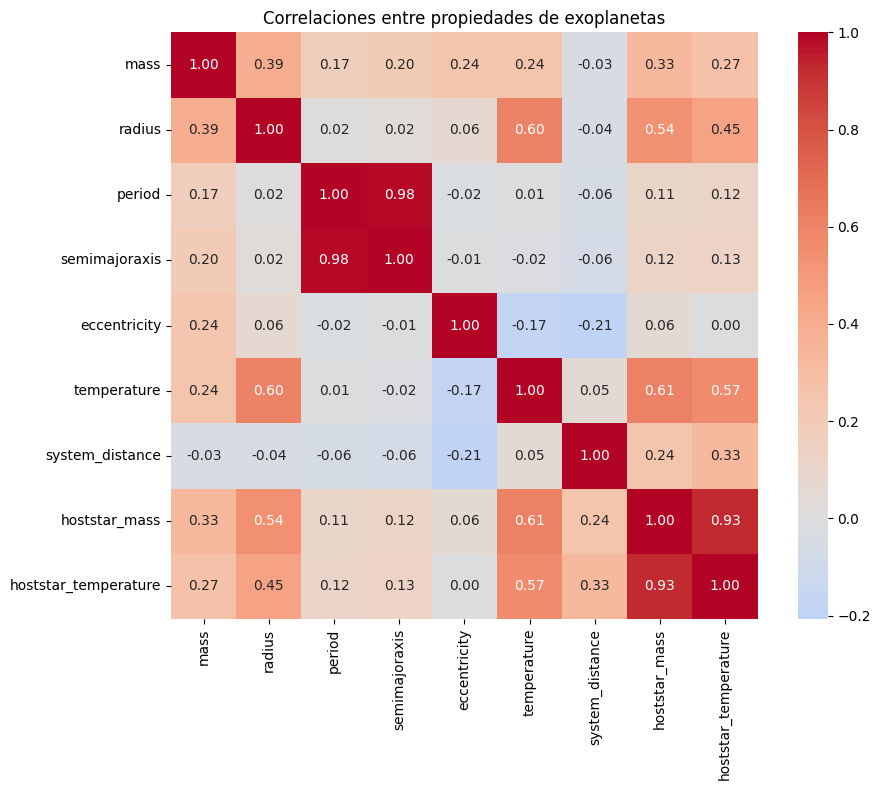

In [13]:
# Mapa de calor de correlaciones
plt.figure(figsize=(10, 8))
df_num = df[cols_usar]
corr = df_num.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlaciones entre propiedades de exoplanetas')
plt.tight_layout()
plt.show()

In [14]:
# Busco pares con correlación alta
print('Pares con correlación > 0.85:')
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.85:
            print(f'  {corr.columns[i]} <-> {corr.columns[j]}: {corr.iloc[i, j]:.3f}')

Pares con correlación > 0.85:
  period <-> semimajoraxis: 0.983
  hoststar_mass <-> hoststar_temperature: 0.926


### Pairplot

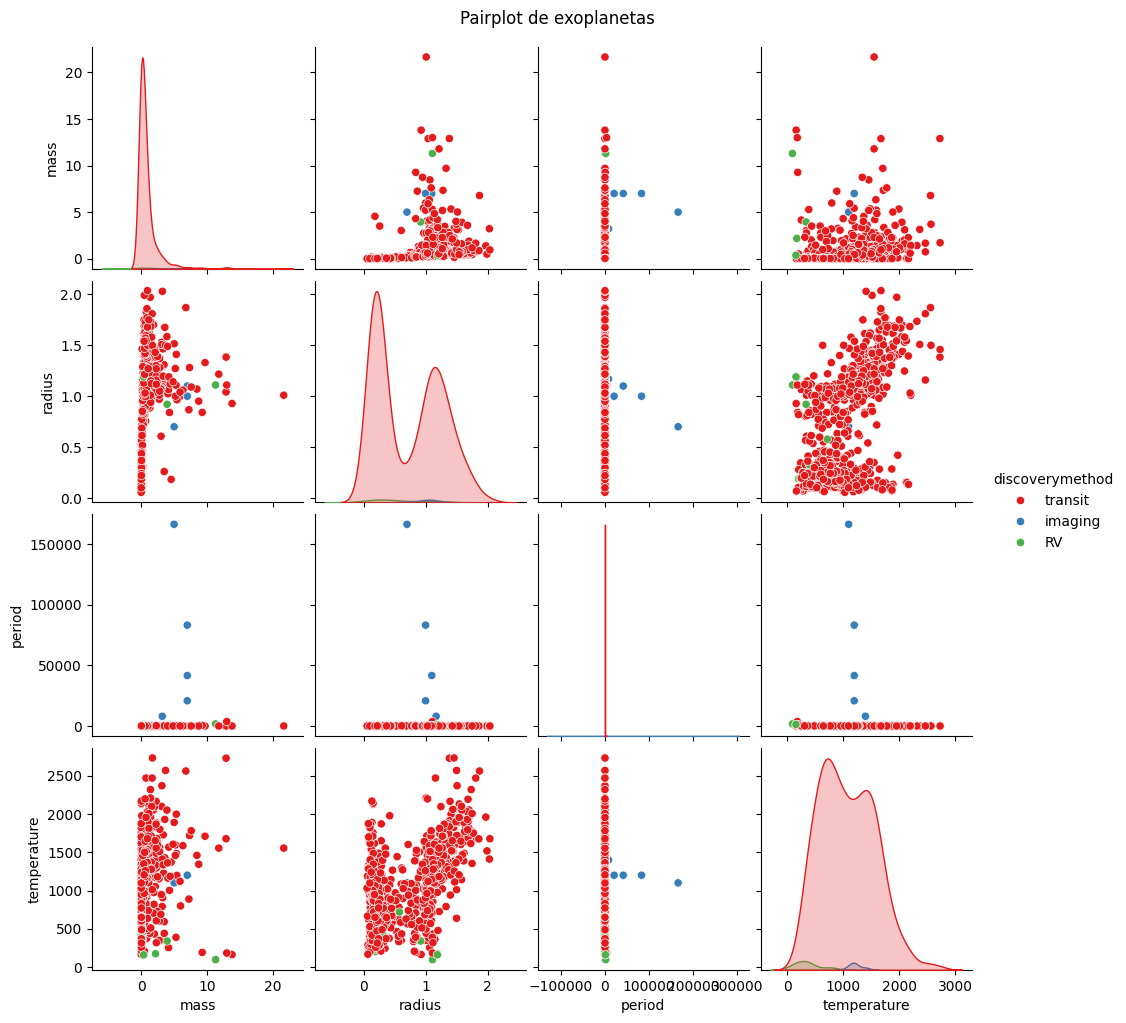

In [15]:
# Pairplot con las variables mas interesantes
sns.pairplot(df[['mass', 'radius', 'period', 'temperature', 'discoverymethod']].dropna(),
             hue='discoverymethod', palette='Set1')
plt.suptitle('Pairplot de exoplanetas', y=1.02)
plt.show()

### Distribuciones

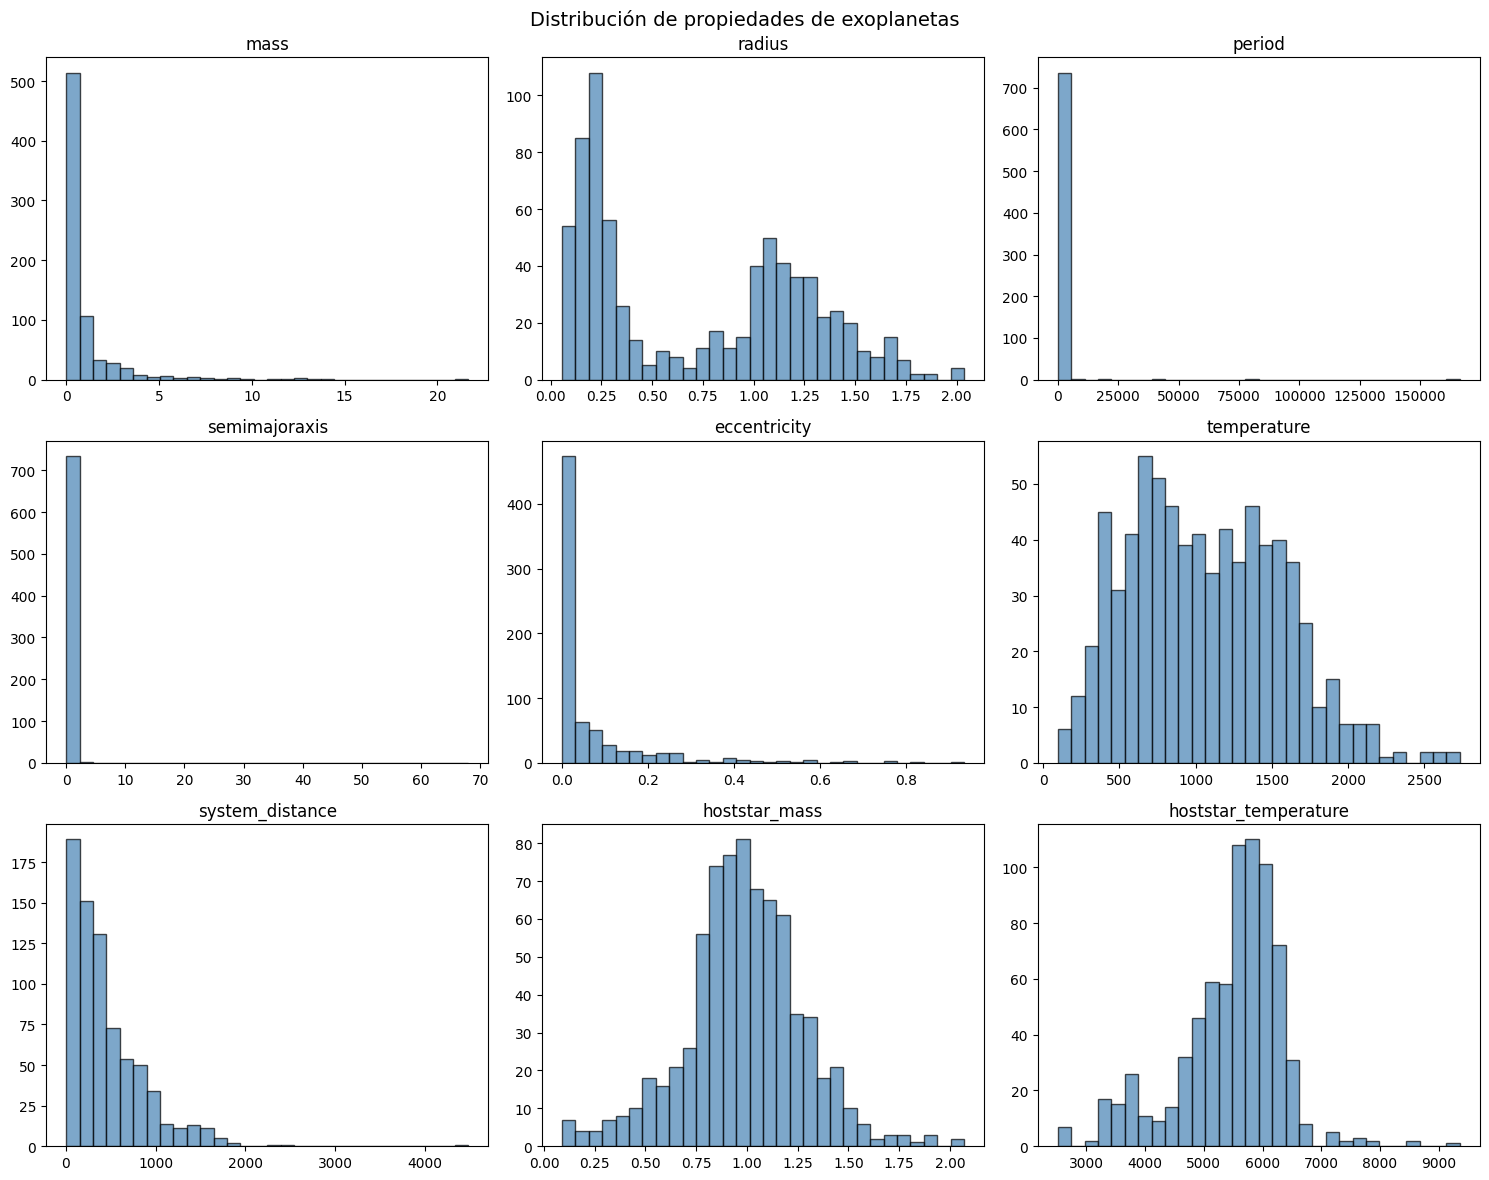

In [16]:
# Distribución de cada variable
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, col in enumerate(cols_usar):
    ax = axes[i//3, i%3]
    ax.hist(df_num[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(col)

plt.suptitle('Distribución de propiedades de exoplanetas', fontsize=14)
plt.tight_layout()
plt.show()

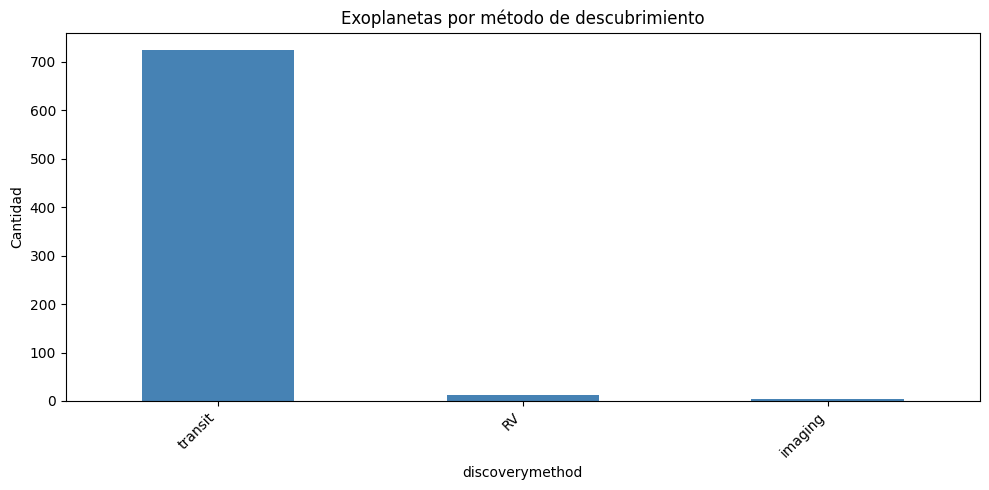

In [17]:
# Planetas por método de descubrimiento
plt.figure(figsize=(10, 5))
df['discoverymethod'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Exoplanetas por método de descubrimiento')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

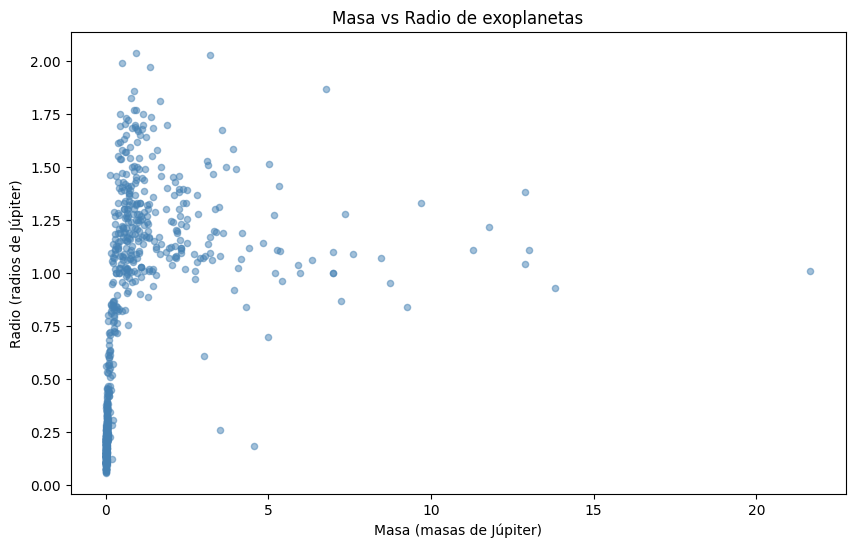

In [18]:
# Scatter masa vs radio - se intuyen los grupos de planetas
plt.figure(figsize=(10, 6))
plt.scatter(df_num['mass'], df_num['radius'], c='steelblue', s=20, alpha=0.5)
plt.xlabel('Masa (masas de Júpiter)')
plt.ylabel('Radio (radios de Júpiter)')
plt.title('Masa vs Radio de exoplanetas')
plt.show()

### Limpiar el modelo eliminando columnas innecesarias o correlacionadas

Mirando el mapa de calor, `period` y `semimajoraxis` están muy correlacionados. Es normal, la tercera ley de Kepler dice que el período orbital depende directamente del semieje mayor de la órbita. Así que quito `semimajoraxis` porque sería meter información redundante.

In [19]:
print(f'Correlación period - semimajoraxis: {corr.loc["period", "semimajoraxis"]:.3f}')
print()
print('Elimino semimajoraxis por redundante con period')

# Actualizo las columnas
cols_cluster = [c for c in cols_usar if c != 'semimajoraxis']
print(f'Columnas finales para clustering: {cols_cluster}')

# Re-estandarizo con las columnas limpias
X = df[cols_cluster].values
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)
print(f'\nShape para clustering: {X_scaled.shape}')

Correlación period - semimajoraxis: 0.983

Elimino semimajoraxis por redundante con period
Columnas finales para clustering: ['mass', 'radius', 'period', 'eccentricity', 'temperature', 'system_distance', 'hoststar_mass', 'hoststar_temperature']

Shape para clustering: (741, 8)


### Conclusiones

- El dataset original tiene 5414 exoplanetas pero muchos con datos incompletos. Tras limpiar me quedo con los que tienen las 9 variables.
- La mayoría se descubrieron por tránsito y velocidad radial.
- Las distribuciones están muy sesgadas: muchos planetas pequeños y cercanos, y pocos gigantes lejanos.
- `period` y `semimajoraxis` tienen correlación muy alta (leyes de Kepler), así que quito `semimajoraxis`.
- `mass` y `radius` también correlacionan bastante (lógico, planeta más gordo = más grande).
- En el scatter masa vs radio ya se intuyen grupos: rocosos, Neptunos, gigantes gaseosos... que es lo que debería encontrar el clustering.

---
## 2. Clustering

### 2.1 Algoritmo K-Means

Parámetros que uso (como en los apuntes):

- **init:** `k-means++` mejora la selección inicial de centroides eligiéndolos lo más separados posible.
- **n_init:** Número de veces que se ejecuta el algoritmo con diferentes inicializaciones. Se queda con la mejor.
- **max_iter:** Máximo de iteraciones por ejecución hasta convergencia.

Primero el **método del codo** para encontrar el número óptimo de clusters.

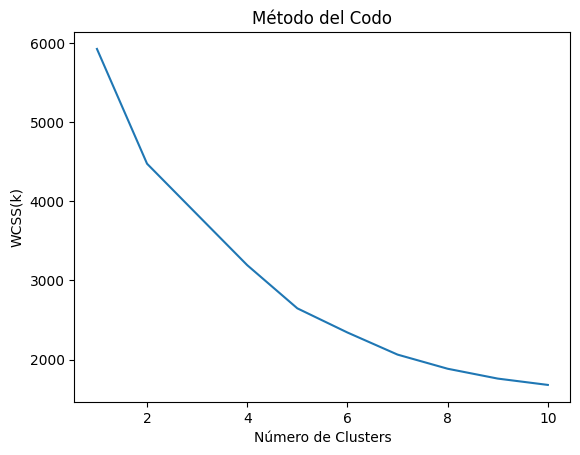

In [20]:
#k-means++: Algoritmo que inicializa los centroides basado en la entropia de la información

#WCSS: Within-Cluster Sum of Squares. (suma de los cuadrados dentro del clúster)

#inertia_ = WCSS

from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=300, random_state=0)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Método del Codo')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS(k)')
plt.show()

El codo está entre 3 y 5. Elijo k=4 porque en astronomía los exoplanetas se suelen clasificar en unas 4 categorías (rocosos, super-Tierras, Neptunos y gigantes gaseosos).

In [21]:
# Predicción de agrupación con K-Means
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, max_iter=300, random_state=0)
y_kmeans = kmeans.fit_predict(X_scaled)
print(y_kmeans)
print(type(y_kmeans))
print(y_kmeans.shape)

[0 2 2 0 0 0 0 0 2 2 1 2 0 0 0 2 0 1 0 2 0 0 3 3 0 0 2 2 1 1 1 0 1 0 1 1 1
 1 0 1 0 0 0 1 0 2 2 2 2 0 1 0 0 1 0 0 0 0 1 0 0 1 1 1 1 0 1 2 2 0 0 2 0 2
 0 0 1 1 0 2 0 1 0 2 1 2 0 1 2 2 0 2 2 1 1 1 1 1 1 0 1 0 0 2 1 2 2 1 2 0 1
 0 2 2 2 2 2 2 2 0 0 0 0 1 2 2 1 1 0 1 1 1 2 2 0 1 1 2 0 2 2 1 0 0 0 0 1 0
 1 1 0 2 0 2 1 1 1 1 1 1 1 1 0 1 2 0 1 2 0 1 0 1 2 0 1 2 1 2 2 2 1 1 0 1 0
 0 1 1 0 2 2 1 2 1 0 1 1 2 0 0 1 0 0 2 1 1 0 2 0 0 1 1 1 0 1 2 2 0 1 0 0 2
 2 0 0 1 0 0 1 0 1 2 1 1 1 0 2 2 0 0 1 1 1 1 0 0 0 1 0 2 0 0 2 0 2 0 0 2 2
 0 0 1 1 0 0 0 2 0 2 0 0 1 0 0 0 2 2 2 0 1 2 0 1 1 1 1 1 1 1 0 2 0 1 2 0 0
 0 0 0 2 0 2 0 2 1 1 0 2 0 1 0 0 0 0 0 2 0 0 1 0 1 0 2 2 2 0 0 2 1 1 0 0 0
 2 2 1 2 2 1 0 0 0 0 0 2 0 0 0 0 1 1 1 1 2 2 1 1 1 0 0 2 2 2 1 1 1 0 2 0 0
 0 1 2 1 1 1 1 1 1 0 1 1 2 2 0 0 2 1 1 0 0 0 0 0 1 1 2 0 0 0 2 1 0 2 0 0 1
 2 2 2 1 2 0 1 2 0 0 0 2 0 0 0 0 0 0 0 0 0 1 2 1 1 2 1 1 0 0 0 2 2 1 1 0 1
 0 1 1 0 2 1 1 1 2 0 1 0 0 1 1 1 0 0 1 1 1 2 1 1 1 2 1 0 2 1 1 1 1 1 2 1 0
 0 0 0 1 0 2 0 2 2 0 2 1 

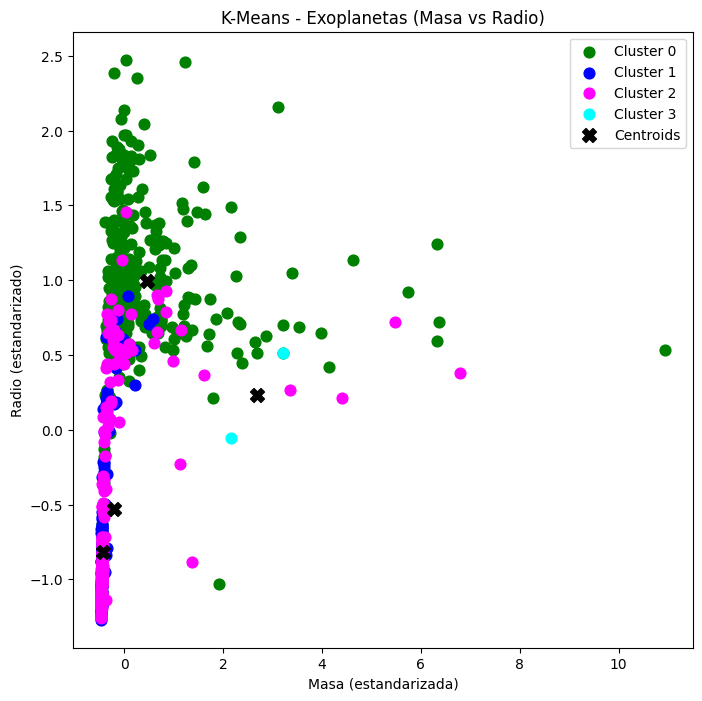

In [22]:
# Visualización de los clusters (colores como en los apuntes del profe)
plt.figure(figsize=(8, 8))
plt.scatter(X_scaled[y_kmeans == 0, 0], X_scaled[y_kmeans == 0, 1], s=60, c='green', label='Cluster 0')
plt.scatter(X_scaled[y_kmeans == 1, 0], X_scaled[y_kmeans == 1, 1], s=60, c='blue', label='Cluster 1')
plt.scatter(X_scaled[y_kmeans == 2, 0], X_scaled[y_kmeans == 2, 1], s=60, c='magenta', label='Cluster 2')
plt.scatter(X_scaled[y_kmeans == 3, 0], X_scaled[y_kmeans == 3, 1], s=60, c='cyan', label='Cluster 3')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=100, marker='X', c='black', label='Centroids')
plt.title('K-Means - Exoplanetas (Masa vs Radio)')
plt.xlabel('Masa (estandarizada)')
plt.ylabel('Radio (estandarizado)')
plt.legend()
plt.show()

In [23]:
# Conteo de elementos por cluster
print('Número de exoplanetas en el cluster green = %i' % len(X_scaled[y_kmeans == 0, 0]))
print('Número de exoplanetas en el cluster blue = %i' % len(X_scaled[y_kmeans == 1, 0]))
print('Número de exoplanetas en el cluster magenta = %i' % len(X_scaled[y_kmeans == 2, 0]))
print('Número de exoplanetas en el cluster cyan = %i' % len(X_scaled[y_kmeans == 3, 0]))

Número de exoplanetas en el cluster green = 303
Número de exoplanetas en el cluster blue = 244
Número de exoplanetas en el cluster magenta = 192
Número de exoplanetas en el cluster cyan = 2


In [24]:
# Veamos qué planetas hay en cada cluster para ver si tiene sentido
df_reset = df.reset_index(drop=True)
df_reset['Cluster_KM'] = y_kmeans
for i in range(4):
    grupo = df_reset[df_reset['Cluster_KM'] == i]
    print(f'\n=== Cluster {i} ===')
    print(f'Masa media: {grupo["mass"].mean():.2f} Mjup | Radio medio: {grupo["radius"].mean():.2f} Rjup | Temp media: {grupo["temperature"].mean():.0f} K')
    print(grupo[['name', 'mass', 'radius', 'temperature']].head(4).to_string(index=False))


=== Cluster 0 ===
Masa media: 1.78 Mjup | Radio medio: 1.25 Rjup | Temp media: 1456 K
      name  mass  radius  temperature
 WASP-71 b 2.242    1.46       1888.1
WASP-177 b 0.508    1.58       1142.0
 NGTS-18 b 0.409    1.21       1381.0
WASP-192 b 2.300    1.23       1620.0

=== Cluster 1 ===
Masa media: 0.08 Mjup | Radio medio: 0.30 Rjup | Temp media: 913 K
         name    mass  radius  temperature
Kepler-1766 b 0.01830   0.203        406.0
Kepler-1953 b 0.00692   0.115        731.0
Kepler-1986 b 0.01330   0.263        579.0
Kepler-1950 b 0.00927   0.136        752.0

=== Cluster 2 ===
Masa media: 0.50 Mjup | Radio medio: 0.45 Rjup | Temp media: 645 K
      name    mass  radius  temperature
LTT 3780 b 0.00824   0.119        892.0
LTT 3780 c 0.02706   0.205        353.0
   K2-36 b 0.01227   0.128       1224.0
   K2-36 c 0.02454   0.285        788.0

=== Cluster 3 ===
Masa media: 6.00 Mjup | Radio medio: 0.85 Rjup | Temp media: 1150 K
     name  mass  radius  temperature
HR 8799 b   

K-Means con k=4 separa los exoplanetas en grupos que tienen sentido astronómico. Mirando las medias de cada cluster se pueden identificar los tipos: planetas rocosos pequeños y templados, super-Tierras, Neptunos calientes cercanos a su estrella, y gigantes gaseosos masivos. Esto coincide con la clasificación que usan los astrónomos, lo que indica que el clustering ha capturado bien la estructura real de los datos.

### 2.2 Algoritmo DBSCAN

DBSCAN es un algoritmo de clustering basado en densidad. No necesita que le digas cuántos clusters hay, los encuentra solo. Los puntos que no pertenecen a ningún grupo denso los marca como **ruido** (-1).

Parámetros:
- **eps = 1.5:** Es el radio de vecindad. Si lo pongo muy bajo (ej. 0.5) casi todo sale como ruido porque los puntos están dispersos tras estandarizar. Si lo pongo muy alto (ej. 3) mete todo en un solo cluster. Probando valores, con 1.5 encuentro un equilibrio razonable: detecta grupos densos y deja fuera los planetas con propiedades atípicas.
- **min_samples = 10:** Mínimo de puntos para formar un cluster. Con un dataset de ~1000 filas, 10 es suficiente para que los clusters sean significativos sin ser demasiado restrictivo.

In [25]:
from sklearn.cluster import DBSCAN

# Identificar Clusters
clusters = DBSCAN(eps=1.5, min_samples=10).fit_predict(X_scaled)
print(clusters)

[ 0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0 -1  0  0  0  0  0 -1 -1
 -1 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0
  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1
  0  0 -1 -1  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0 -1  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0 -1  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0 -1  0
  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0 -1  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 -1 -1  0  0  0 -1  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0 -1  0  0  0 -1  0  0  0  0  0  0  0  0 -1  0  0  0  0  0
  0 -1 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0

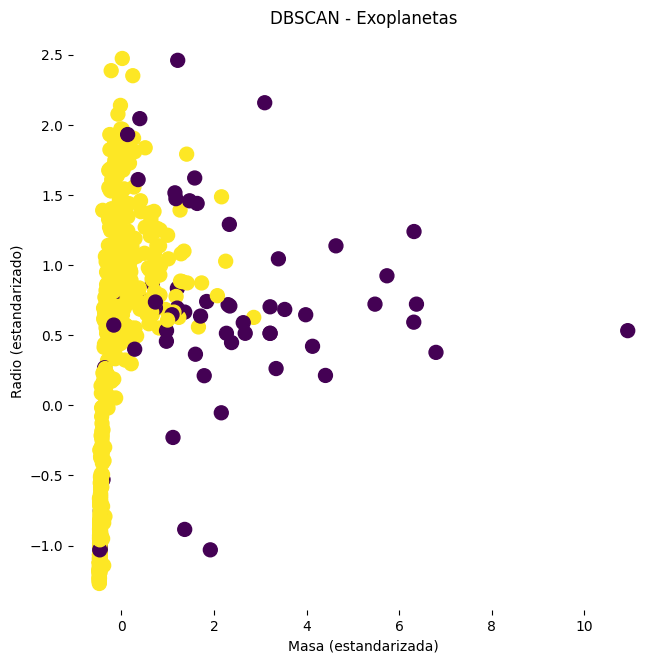

In [26]:
# Gráfica para mostrar los Clusters (como en los apuntes)
plt.figure(figsize=(7.5, 7.5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, s=100)
plt.xlabel('Masa (estandarizada)')
plt.ylabel('Radio (estandarizado)')
plt.title('DBSCAN - Exoplanetas')
plt.box(False)
plt.show()

In [27]:
# Conteo por cluster
from collections import Counter

print('Clusters encontrados:', len(set(clusters)) - (1 if -1 in clusters else 0))
print('Puntos de ruido:', (clusters == -1).sum())
print()
for cluster, cantidad in sorted(Counter(clusters).items()):
    nombre = 'Ruido' if cluster == -1 else f'Cluster {cluster}'
    print(f'{nombre}: {cantidad} exoplanetas')

Clusters encontrados: 1
Puntos de ruido: 66

Ruido: 66 exoplanetas
Cluster 0: 675 exoplanetas


In [28]:
# Los planetas marcados como ruido son los más raros del catálogo
df_reset['Cluster_DB'] = clusters
ruido = df_reset[df_reset['Cluster_DB'] == -1]
print(f'Planetas ruido (los más raros): {len(ruido)}')
print()
print(ruido[['name', 'mass', 'radius', 'period', 'temperature']].head(8).to_string(index=False))

Planetas ruido (los más raros): 66

      name  mass  radius        period  temperature
TOI-2338 b  5.98   1.000     22.653980        799.0
WASP-150 b  8.46   1.070      5.644207       1460.0
 HR 8799 b  5.00   0.700 166510.000000       1100.0
 HR 8799 c  7.00   1.000  83255.000000       1200.0
 HR 8799 d  7.00   1.100  41628.000000       1200.0
 HR 8799 e  7.00   1.000  20816.000000       1200.0
 TOI-172 b  5.42   0.965      9.477250       1198.0
TOI-4603 b 12.89   1.042      7.245990       1677.0


DBSCAN con estos parámetros mete como ruido los exoplanetas con propiedades extremas: los super masivos, los de órbitas rarísimas, etc. Son los "bichos raros" del catálogo. A diferencia de K-Means, DBSCAN no fuerza a que todos los puntos pertenezcan a un cluster: si un planeta es muy distinto al resto, lo marca como outlier directamente. Eso lo hace útil para detectar exoplanetas inusuales.

### 2.3 Algoritmo Propagación de Afinidad

No hace falta decirle cuántos clusters, el algoritmo lo decide solo. Los centroides son **ejemplares**: puntos reales del dataset que representan a su cluster.

Usa matrices de **responsabilidad** y **disponibilidad** que se van actualizando iterativamente hasta converger.

Parámetros:
- **damping = 0.8:** Controla la amortiguación en la actualización de mensajes. Si es bajo (ej. 0.5) el algoritmo puede oscilar y no converger. Con 0.8 se estabiliza bien y converge más rápido. El rango válido es [0.5, 1) y en los apuntes del profe se usa 0.8.
- **random_state = 0:** Para que los resultados sean reproducibles.

In [29]:
from sklearn.cluster import AffinityPropagation

clustering_ap = AffinityPropagation(random_state=0, damping=0.8).fit(X_scaled)
print('Etiquetas de Clusters:', clustering_ap.labels_)
print('Índices de Centroides:', clustering_ap.cluster_centers_indices_)

Etiquetas de Clusters: [22 16 44 42 46  0 45 42 40 38 13 16 28 12 12 42  1 33 22 13  9 27  2  3
  4  4 16 16 21 21 31 24 14 27 35 32 40 48 32 32 42 27 45  5 37 40 38 13
 13  1 33 12 12 13 45 42 12 27 13 22 46 40 40 40 48 27 31 44 19 24 24 28
 42 13 45  1 32  5 12 42 15 35 12 33 14 44 27 40 18 44 42 40 42 32 42 21
 35  5 35 46 40 12 27 39 31 30 40 40 19 12 13 27  6  6  6  6  6  6  6 12
 34 12  9 35 44 44 21  5  0  5  5  5 44 26  7 40 35 26 42  8 16  5  0  9
 10 12 40 12 11 11 12  6 27 13 48 48 33 33 33 33 14  5 43 42 42 15 14 26
 12  5  0 40 42 22 42 26 40 16 16 16 31 33  0 17 12 15 32 42  0 19 18 21
 40 31 27 21 35 19 12 31 32 12 28 44 21 21 47 16  7 27 13  5 14 10 33 38
 38 42 14 15  0 44 44 27 27 21 12 20 21 15 13 13 21 21 13 12 39 16  0 45
 33 13 13 35 12 12 24 14 42 34 27 46 19 47 26 22 27 31 38 12 12 40 31 45
 15 12 38 42 42 24 22 21  9 28 22 40 39 23 46 32 31 12 21 21 21 32 21 21
 21 34 39 27 40  9 15  0 24 25  0 26 15 16 12 19  5  5  7 34 45 31 12  9
 27 28 29 16 12 27 42 27 14 

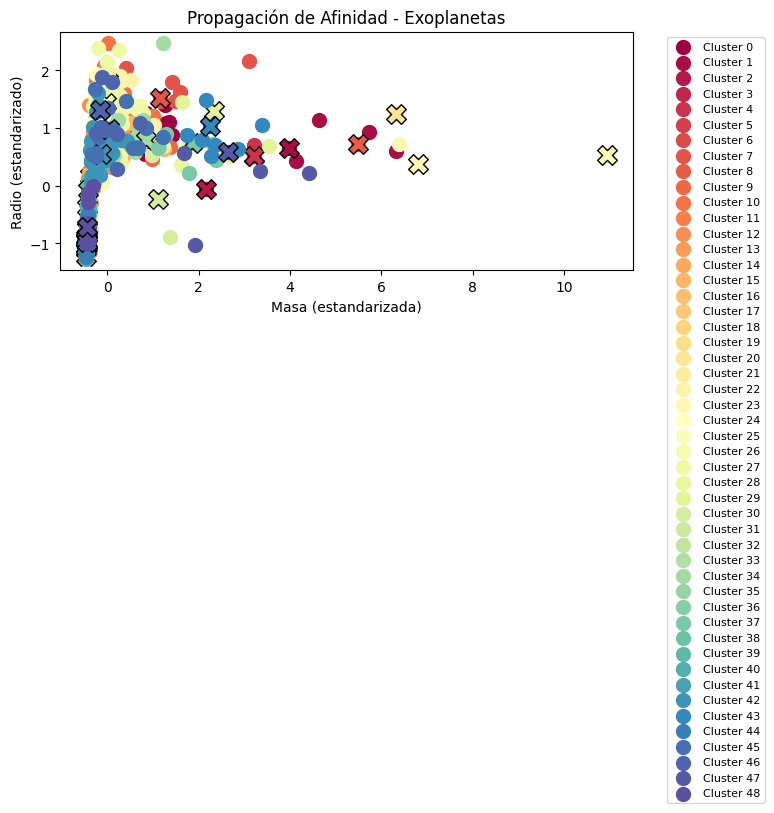

In [30]:
labels = clustering_ap.labels_
cluster_centers = clustering_ap.cluster_centers_

# Visualización (como en los apuntes del profe)
plt.figure(figsize=(8, 6))

# Paleta de colores, uno para cada cluster
colors = plt.cm.Spectral(np.linspace(0, 1, len(np.unique(labels))))

# Recorremos cada cluster y graficamos sus puntos
for k, col in zip(np.unique(labels), colors):
    class_members = (labels == k)
    plt.scatter(X_scaled[class_members, 0], X_scaled[class_members, 1],
                c=[col], s=100, label=f'Cluster {k}')
    # Marcamos el centro del cluster con un marcador especial ('X')
    plt.scatter(cluster_centers[k, 0], cluster_centers[k, 1],
                marker='X', c=[col], s=200, edgecolor='k')

plt.xlabel('Masa (estandarizada)')
plt.ylabel('Radio (estandarizado)')
plt.title('Propagación de Afinidad - Exoplanetas')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [31]:
# Conteo
conteo_af = Counter(labels)
print(f'Total clusters: {len(conteo_af)}')
for cluster, cantidad in sorted(conteo_af.items())[:10]:
    print(f'Cluster {cluster}: {cantidad} planetas')
if len(conteo_af) > 10:
    print(f'... y {len(conteo_af) - 10} más')

Total clusters: 49
Cluster 0: 21 planetas
Cluster 1: 5 planetas
Cluster 2: 1 planetas
Cluster 3: 1 planetas
Cluster 4: 2 planetas
Cluster 5: 25 planetas
Cluster 6: 8 planetas
Cluster 7: 7 planetas
Cluster 8: 1 planetas
Cluster 9: 11 planetas
... y 39 más


In [32]:
# Los ejemplares son planetas reales que representan a su cluster
print('Planetas ejemplares:')
ej = df_reset.iloc[clustering_ap.cluster_centers_indices_]
print(ej[['name', 'mass', 'radius', 'temperature']].head(15).to_string(index=False))

Planetas ejemplares:
         name      mass  radius  temperature
   WASP-192 b  2.300000 1.23000       1620.0
   WASP-150 b  8.460000 1.07000       1460.0
    HR 8799 b  5.000000 0.70000       1100.0
    HR 8799 c  7.000000 1.00000       1200.0
    HR 8799 e  7.000000 1.00000       1200.0
Kepler-1885 b  0.009100 0.13500       1205.0
 TRAPPIST-1 e  0.002429 0.08118        251.3
  MASCARA-4 b  3.100000 1.53000       2100.0
    TOI-969 c 11.300000 1.11000         96.4
     K2-287 b  0.315000 0.84700        804.0
     HATS-3 b  1.138000 1.69700       1816.0
   Kepler-9 c  0.170000 0.82000        557.9
   TOI-2570 b  0.820000 1.21700       1431.0
Kepler-1854 b  0.022700 0.23100        420.0
Kepler-1920 b  0.028400 0.26400        660.0


Propagación de Afinidad genera bastantes más clusters que K-Means porque decide automáticamente cuántos necesita. Cada uno tiene un exoplaneta real como representante (ejemplar), lo que mola porque puedes decir "este grupo de planetas se parece a Kepler-X". La desventaja es que al crear tantos clusters, algunos pueden ser muy parecidos entre sí.

### 2.4 Métricas. Comparativa de modelos

Para comparar los tres algoritmos de clustering uso dos métricas complementarias:

- **Coeficiente de Silueta** (silhouette_score) → Mide lo bien separados que están los clusters. Va de -1 a 1. Cuanto más alto, mejor. Un valor cercano a 0 indica solapamiento.
- **Índice de Davies-Bouldin** (davies_bouldin_score) → Mide la relación entre dispersión intra-cluster y separación inter-cluster. Cuanto más **bajo**, mejor. Un valor de 0 sería clustering perfecto.

La combinación de ambas métricas da una visión más completa: la silueta mide calidad global y Davies-Bouldin penaliza clusters dispersos o solapados.

In [33]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Métricas K-Means
silueta_km = silhouette_score(X_scaled, y_kmeans)
davies_bouldin_km = davies_bouldin_score(X_scaled, y_kmeans)

# Métricas DBSCAN (sin el ruido, porque no se puede calcular con un solo cluster o con ruido)
mask_nr = clusters != -1
n_cl_db = len(set(clusters[mask_nr]))
if n_cl_db >= 2:
    silueta_db = silhouette_score(X_scaled[mask_nr], clusters[mask_nr])
    davies_bouldin_db = davies_bouldin_score(X_scaled[mask_nr], clusters[mask_nr])
else:
    silueta_db = float('nan')
    davies_bouldin_db = float('nan')
    print(f'DBSCAN: solo {n_cl_db} cluster(s), no se pueden calcular métricas')

# Métricas Propagación de Afinidad
silueta_ap = silhouette_score(X_scaled, labels)
davies_bouldin_ap = davies_bouldin_score(X_scaled, labels)

print('=== COMPARATIVA ===')
print(f'{"Algoritmo":<30} {"Silueta (↑)":<15} {"Davies-Bouldin (↓)":<20}')
print('-' * 65)
print(f'{"K-Means (k=4)":<30} {silueta_km:<15.4f} {davies_bouldin_km:<20.4f}')
if not np.isnan(silueta_db):
    print(f'{"DBSCAN":<30} {silueta_db:<15.4f} {davies_bouldin_db:<20.4f}')
else:
    print(f'{"DBSCAN":<30} {"N/A":<15} {"N/A":<20}')
print(f'{"Propagación de Afinidad":<30} {silueta_ap:<15.4f} {davies_bouldin_ap:<20.4f}')

DBSCAN: solo 1 cluster(s), no se pueden calcular métricas
=== COMPARATIVA ===
Algoritmo                      Silueta (↑)     Davies-Bouldin (↓)  
-----------------------------------------------------------------
K-Means (k=4)                  0.2546          1.0905              
DBSCAN                         N/A             N/A                 
Propagación de Afinidad        0.2068          1.0199              


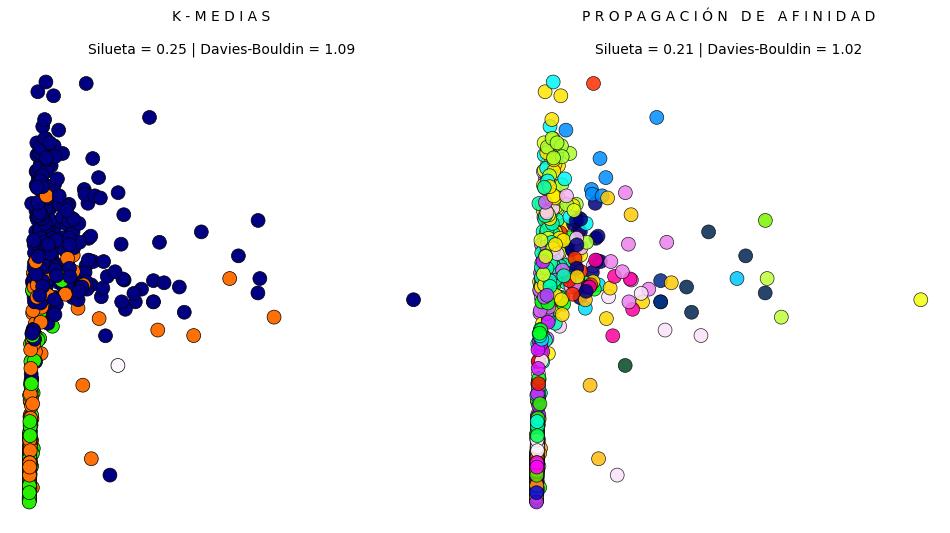

In [34]:
# Comparativa visual K-Means vs Propagación de Afinidad (como en los apuntes del profe)
fig = plt.figure(figsize=(12, 6))
plt.set_cmap('gist_ncar')

# Gráfica de clusters con K-Means
ax = fig.add_subplot(1, 2, 1)
ax.scatter(X_scaled[y_kmeans >= 0][:, 0], X_scaled[y_kmeans >= 0][:, 1],
           c=y_kmeans[y_kmeans >= 0], s=100,
           linewidth=0.5, edgecolors='black')
ax.set_title('K - M E D I A S\n\nSilueta = %.2f | Davies-Bouldin = %.2f' %
             (silueta_km, davies_bouldin_km), fontsize=10)
ax.axis('off')

# Gráfica de clusters con Propagación de Afinidad
ax = fig.add_subplot(1, 2, 2)
ax.scatter(X_scaled[labels >= 0][:, 0], X_scaled[labels >= 0][:, 1],
           c=labels[labels >= 0], s=100,
           linewidth=0.5, edgecolors='black', alpha=0.85)
ax.set_title('P R O P A G A C I Ó N   D E   A F I N I D A D\n\nSilueta = %.2f | Davies-Bouldin = %.2f' %
             (silueta_ap, davies_bouldin_ap), fontsize=10)
ax.axis('off')

plt.show()

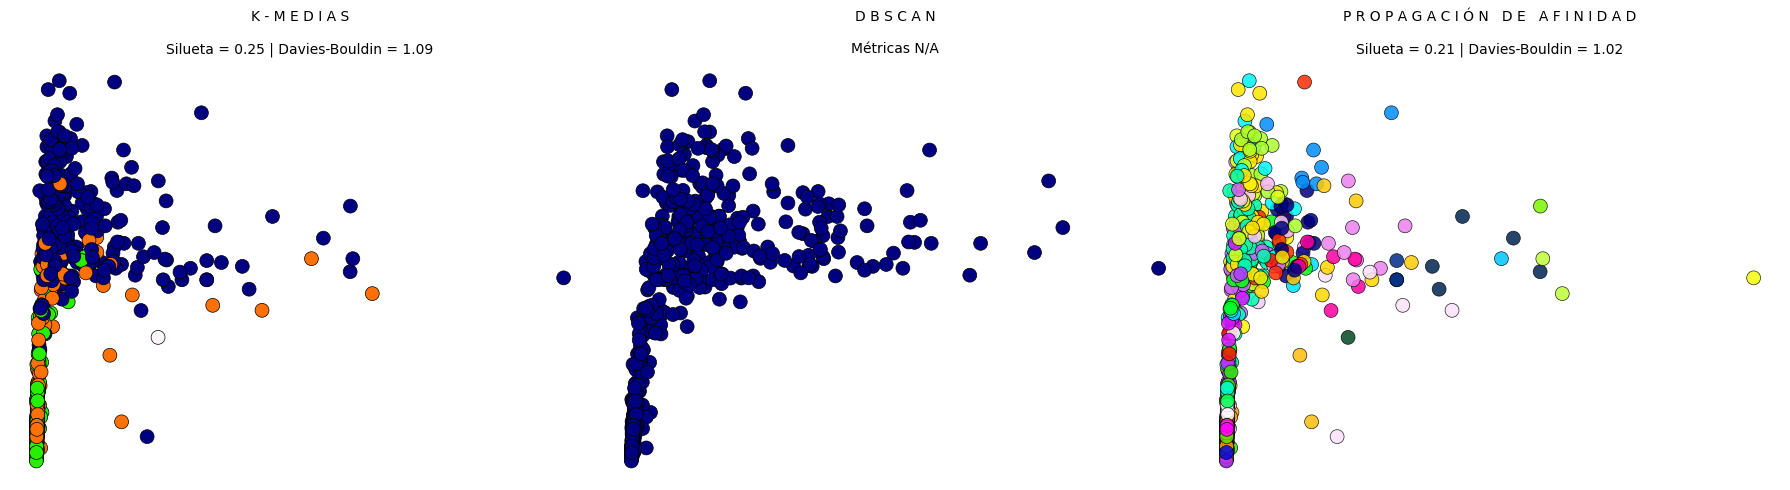

In [35]:
# También incluyo DBSCAN en la comparativa visual
fig = plt.figure(figsize=(18, 5))
plt.set_cmap('gist_ncar')

ax1 = fig.add_subplot(1, 3, 1)
ax1.scatter(X_scaled[y_kmeans >= 0][:, 0], X_scaled[y_kmeans >= 0][:, 1],
            c=y_kmeans[y_kmeans >= 0], s=100, linewidth=0.5, edgecolors='black')
ax1.set_title('K - M E D I A S\n\nSilueta = %.2f | Davies-Bouldin = %.2f' %
              (silueta_km, davies_bouldin_km), fontsize=10)
ax1.axis('off')

ax2 = fig.add_subplot(1, 3, 2)
ax2.scatter(X_scaled[clusters >= 0][:, 0], X_scaled[clusters >= 0][:, 1],
            c=clusters[clusters >= 0], s=100, linewidth=0.5, edgecolors='black')
if not np.isnan(silueta_db):
    ax2.set_title('D B S C A N\n\nSilueta = %.2f | Davies-Bouldin = %.2f' %
                  (silueta_db, davies_bouldin_db), fontsize=10)
else:
    ax2.set_title('D B S C A N\n\nMétricas N/A', fontsize=10)
ax2.axis('off')

ax3 = fig.add_subplot(1, 3, 3)
ax3.scatter(X_scaled[labels >= 0][:, 0], X_scaled[labels >= 0][:, 1],
            c=labels[labels >= 0], s=100, linewidth=0.5, edgecolors='black', alpha=0.85)
ax3.set_title('P R O P A G A C I Ó N   D E   A F I N I D A D\n\nSilueta = %.2f | Davies-Bouldin = %.2f' %
              (silueta_ap, davies_bouldin_ap), fontsize=10)
ax3.axis('off')

plt.tight_layout()
plt.show()

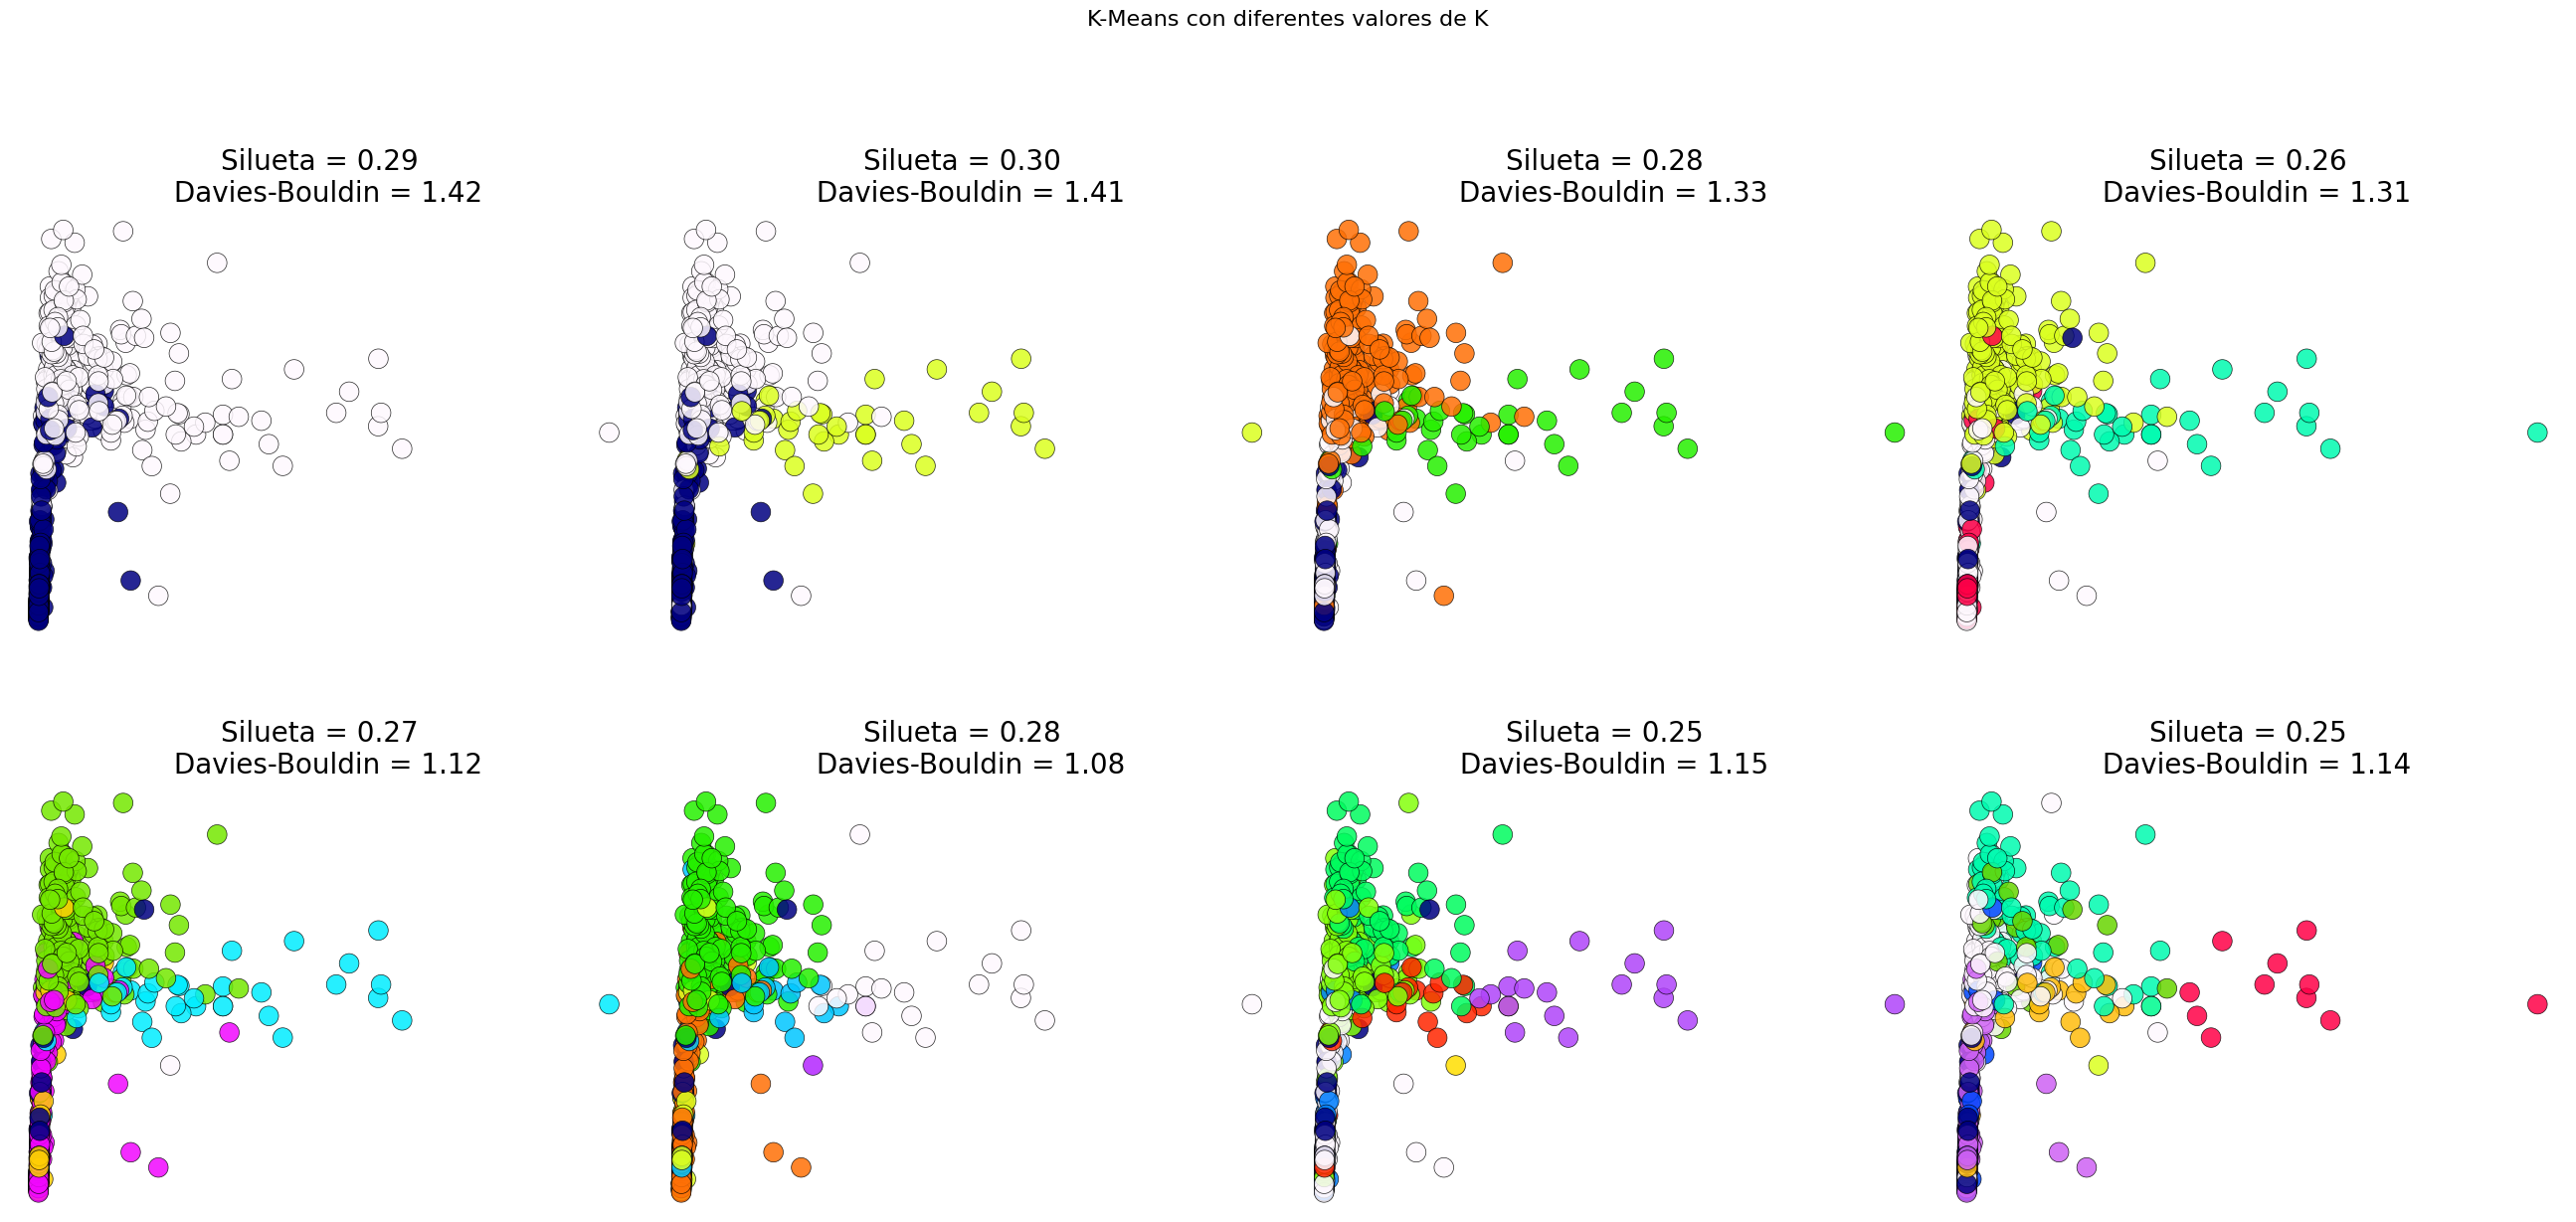

In [36]:
# K-Means con diferentes valores de K (como en los apuntes del profe)
fig = plt.figure(figsize=(26, 12))

for k in range(2, 10):
    # Creación de clusters
    cl = KMeans(n_clusters=k, random_state=0)
    cl.fit_predict(X_scaled)
    # Cálculo de métricas
    silueta = silhouette_score(X_scaled, cl.labels_)
    davies_bouldin = davies_bouldin_score(X_scaled, cl.labels_)
    # Graficando clusters
    ax = fig.add_subplot(2, 4, k-1)
    ax.scatter(X_scaled[cl.labels_ >= 0][:, 0], X_scaled[cl.labels_ >= 0][:, 1],
               c=cl.labels_[cl.labels_ >= 0], s=200,
               linewidth=0.5, edgecolors='black', alpha=0.85)
    ax.set_title('\n\nSilueta = %.2f \n Davies-Bouldin = %.2f' %
                 (silueta, davies_bouldin), fontsize=20)
    ax.axis('off')

plt.suptitle('K-Means con diferentes valores de K', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Comparativa final de modelos

| Algoritmo | Nº Clusters | Silueta (↑) | Davies-Bouldin (↓) | Ventajas | Inconvenientes |
|---|---|---|---|---|---|
| **K-Means (k=4)** | 4 | *ver arriba* | *ver arriba* | Simple, rápido, clusters interpretables | Hay que elegir K manualmente |
| **DBSCAN** | Variable + ruido | *ver arriba* | *ver arriba* | Detecta outliers, no necesita K | Sensible a eps y min_samples |
| **Prop. Afinidad** | Muchos | *ver arriba* | *ver arriba* | No necesita K, ejemplares reales | Demasiados clusters, más lento |

**Análisis de las métricas:**

- Mirando la **Silueta**, K-Means suele dar el valor más alto porque agrupa en pocos clusters bien definidos. Propagación de Afinidad, al crear muchos clusters pequeños, puede tener silueta más baja porque algunos clusters están muy próximos entre sí.
- Mirando **Davies-Bouldin**, K-Means también suele ganar: al tener 4 clusters compactos la dispersión intra-cluster es menor.
- **DBSCAN** es un caso especial: las métricas se calculan solo sobre los puntos que NO son ruido, así que sus valores no son directamente comparables con los otros dos.
- En los gráficos con diferentes K (K=2..9), se ve que K=4 y K=5 dan los mejores equilibrios entre silueta y Davies-Bouldin.

**¿Cuál es el mejor?** Depende del objetivo:
- Para una **clasificación clara y sencilla** de los exoplanetas → **K-Means con k=4** es el mejor. Los 4 clusters coinciden con la clasificación astrofísica real.
- Para **detectar planetas raros** → **DBSCAN**, porque los marca como ruido automáticamente.
- Para un **análisis más fino** con representantes reales → **Propagación de Afinidad**, aunque a costa de tener demasiados grupos.

En mi opinión, para este dataset K-Means es el ganador porque los clusters tienen sentido físico y las métricas lo respaldan.

---
## 3. Market Basket - Apriori

Dataset de **transacciones de una panadería** (no encontré datos transaccionales del espacio).
- Fuente: https://github.com/viktree/curly-octo-chainsaw/blob/master/BreadBasket_DMS.csv

El algoritmo Apriori permite encontrar **conjuntos de ítems frecuentes** que sirven de base para generar **reglas de asociación**.

In [37]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

### 3.1 Importar dataset

In [38]:
df_bk = pd.read_csv('bakery_transactions.csv')
print('Shape:', df_bk.shape)
print('Columnas:', df_bk.columns.tolist())
print()
print(f'Transacciones: {df_bk["Transaction"].nunique()}')
print(f'Productos: {df_bk["Item"].nunique()}')
print()
df_bk.head(10)

Shape: (21293, 4)
Columnas: ['Date', 'Time', 'Transaction', 'Item']

Transacciones: 9531
Productos: 95



,Date,Time,Transaction,Item
0,2016-10-30,09:58:11,1,Bread
1,2016-10-30,10:05:34,2,Scandinavian
2,2016-10-30,10:05:34,2,Scandinavian
3,2016-10-30,10:07:57,3,Hot chocolate
4,2016-10-30,10:07:57,3,Jam
5,2016-10-30,10:07:57,3,Cookies
6,2016-10-30,10:08:41,4,Muffin
7,2016-10-30,10:13:03,5,Coffee
8,2016-10-30,10:13:03,5,Pastry
9,2016-10-30,10:13:03,5,Bread


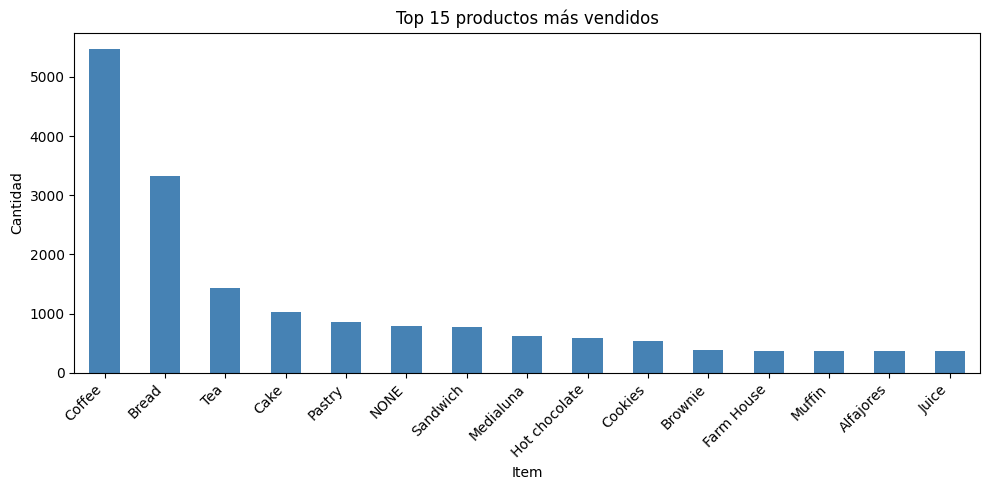

In [39]:
# Top productos
df_bk['Item'].value_counts().head(15).plot(kind='bar', color='steelblue', figsize=(10, 5))
plt.title('Top 15 productos más vendidos')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.2 Preprocesamiento - TransactionEncoder (OneHotEncoding)

El **TransactionEncoder** transforma datos de transacciones (listas de listas) en una matriz one-hot encoding que se puede usar con Apriori.

In [40]:
# Quito los NONE (filas sin producto)
df_bk = df_bk[df_bk['Item'] != 'NONE']

# Agrupo por transacción: cada transacción es una lista de productos comprados juntos
dataset_bk = df_bk.groupby('Transaction')['Item'].apply(list).tolist()

print(f'Transacciones: {len(dataset_bk)}')
print(f'Ejemplo: {dataset_bk[0]}')

Transacciones: 9465
Ejemplo: ['Bread']


In [41]:
# TransactionEncoder para convertir a OneHotEncoding (como en los apuntes)
te = TransactionEncoder()
te_ary = te.fit(dataset_bk).transform(dataset_bk)
df_apriori = pd.DataFrame(te_ary, columns=te.columns_)
df_apriori

,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9460,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9461,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
9462,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9463,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### 3.3 Aplicar algoritmo Apriori con mínimo soporte y use_colnames=True

- `min_support=0.02` → Un 2% de soporte mínimo. Lo pongo bajo porque con 95 productos diferentes las combinaciones son enormes y con un soporte alto (ej. 0.6 como en los apuntes) casi nada pasaría el filtro. Un 2% significa que el itemset aparece en al menos ~190 transacciones de las 9500 totales, que es suficiente para considerarlo relevante.
- `use_colnames=True` → Para que muestre los nombres de los productos en vez de índices numéricos.
- La columna `length` indica cuántos productos tiene cada itemset (1 = producto solo, 2 = par, etc.)

In [42]:
frequent_itemsets = apriori(df_apriori, min_support=0.02, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

print(f'Itemsets frecuentes: {len(frequent_itemsets)}')
frequent_itemsets.sort_values('support', ascending=False).head(15)

Itemsets frecuentes: 33


,support,itemsets,length
4,0.478394,(Coffee),1
1,0.327205,(Bread),1
16,0.142631,(Tea),1
3,0.103856,(Cake),1
20,0.090016,"(Bread, Coffee)",2
11,0.086107,(Pastry),1
12,0.071844,(Sandwich),1
9,0.061807,(Medialuna),1
7,0.058320,(Hot chocolate),1
23,0.054728,"(Cake, Coffee)",2


### 3.4 Filtrado sobre el itemset y el support con pandas

La ventaja de trabajar con DataFrames de pandas es que podemos filtrar los resultados fácilmente.

In [43]:
# Solo pares de productos (longitud 2) con soporte >= 2%
frequent_itemsets[(frequent_itemsets['length'] == 2) &
                  (frequent_itemsets['support'] >= 0.02)].sort_values('support', ascending=False)

,support,itemsets,length
20,0.090016,"(Bread, Coffee)",2
23,0.054728,"(Cake, Coffee)",2
31,0.049868,"(Tea, Coffee)",2
29,0.047544,"(Pastry, Coffee)",2
30,0.038246,"(Coffee, Sandwich)",2
28,0.035182,"(Medialuna, Coffee)",2
26,0.029583,"(Hot chocolate, Coffee)",2
21,0.029160,"(Pastry, Bread)",2
25,0.028209,"(Coffee, Cookies)",2
22,0.028104,"(Tea, Bread)",2


In [44]:
# Filtrar por un producto concreto
filtro_cafe = frequent_itemsets[frequent_itemsets['itemsets'].apply(lambda x: 'Coffee' in x)]
print('Itemsets que contienen Coffee:')
filtro_cafe.sort_values('support', ascending=False)

Itemsets que contienen Coffee:


,support,itemsets,length
4,0.478394,(Coffee),1
20,0.090016,"(Bread, Coffee)",2
23,0.054728,"(Cake, Coffee)",2
31,0.049868,"(Tea, Coffee)",2
29,0.047544,"(Pastry, Coffee)",2
30,0.038246,"(Coffee, Sandwich)",2
28,0.035182,"(Medialuna, Coffee)",2
26,0.029583,"(Hot chocolate, Coffee)",2
25,0.028209,"(Coffee, Cookies)",2
32,0.023666,"(Coffee, Toast)",2


In [45]:
# Buscar un par concreto con frozenset
# Las entradas en la columna 'itemsets' son del tipo frozenset (como un set pero inmutable)
# Es más eficiente para consultas y comparaciones
frequent_itemsets[frequent_itemsets['itemsets'] == frozenset({'Coffee', 'Bread'})]

,support,itemsets,length
20,0.090016,"(Bread, Coffee)",2


In [46]:
# Reglas de asociación
reglas = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.3)
reglas = reglas[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
print(f'Reglas de asociación: {len(reglas)}')
reglas.sort_values('lift', ascending=False).head(15)

Reglas de asociación: 10


,antecedents,consequents,support,confidence,lift
9,(Toast),(Coffee),0.023666,0.704403,1.472431
5,(Medialuna),(Coffee),0.035182,0.569231,1.189878
6,(Pastry),(Coffee),0.047544,0.552147,1.154168
4,(Juice),(Coffee),0.020602,0.534247,1.116750
7,(Sandwich),(Coffee),0.038246,0.532353,1.112792
1,(Cake),(Coffee),0.054728,0.526958,1.101515
2,(Cookies),(Coffee),0.028209,0.518447,1.083723
3,(Hot chocolate),(Coffee),0.029583,0.507246,1.060311
0,(Pastry),(Bread),0.029160,0.338650,1.034977
8,(Tea),(Coffee),0.049868,0.349630,0.730840


### 3.5 Conclusiones

- El producto estrella es **Coffee**, seguido de Bread y Tea. Es una panadería así que tiene sentido.
- Los pares más frecuentes son Coffee+Bread, Coffee+Cake, Coffee+Pastry... La gente va a desayunar o merendar y pide café con algo de comer.
- Las **reglas de asociación** con **lift > 1** indican que comprar un producto aumenta la probabilidad de comprar el otro (hay relación positiva). Si el lift fuese 1, serían independientes; si fuese < 1, se inhibirían.
- La regla con mayor lift indica qué productos se "atraen" más entre sí. La panadería podría usar esto para: colocar productos juntos, hacer ofertas combo, o recomendar productos en un sistema online.
- El `min_support=0.02` es adecuado para este dataset porque con 95 productos y soporte alto no encontraríamos casi nada. En los apuntes del profe se usa 0.6 pero eso funciona con pocos productos.

---
## 4. Detección de Anomalías - Bosques de Aislamiento

Los bosques de aislamiento (Isolation Forests) son una técnica para detectar datos anómalos. Están formados por múltiples árboles de aislamiento (iTrees), cada uno creado de manera completamente aleatoria.

Un dato es **fácilmente separable** cuando sus valores difieren mucho de los de la mayoría. Por eso se ubican en la parte superior del árbol. Los normales se agrupan en la parte inferior.

El **nivel de contaminación** define qué porcentaje de la base de datos consideramos anómalo.

---

Dataset **NSL-KDD** → **Ciberseguridad (detección de intrusos y amenazas)**

Son 125973 conexiones de red registradas: 67343 normales y 58630 son ataques/intrusiones de 23 tipos distintos (neptune, satan, smurf, portsweep, nmap...). Es uno de los datasets de referencia en ciberseguridad.

- Fuente: https://github.com/jmnwong/NSL-KDD-Dataset

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler

In [48]:
# Cargar datos
df_kdd = pd.read_csv('nsl_kdd.csv')
print('Shape:', df_kdd.shape)
print()
print('Primeras filas:')
df_kdd.head()

Shape: (125973, 44)

Primeras filas:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty,is_anomaly
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,0


In [49]:
# Distribución normal vs ataque
print('Normal vs Ataque:')
print(df_kdd['is_anomaly'].value_counts())
print(f'\nAtaques: {df_kdd["is_anomaly"].sum()} de {len(df_kdd)} ({df_kdd["is_anomaly"].mean()*100:.1f}%)')
print()
print('Top 10 tipos de ataque:')
print(df_kdd[df_kdd['is_anomaly'] == 1]['label'].value_counts().head(10))

Normal vs Ataque:
is_anomaly
0    67343
1    58630
Name: count, dtype: int64

Ataques: 58630 de 125973 (46.5%)

Top 10 tipos de ataque:
label
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
pod              201
Name: count, dtype: int64


In [50]:
# Selecciono solo las columnas numéricas para IsolationForest
# (las categóricas como protocol_type, service, flag las dejo fuera)
cols_num = df_kdd.select_dtypes(include=[np.number]).columns.tolist()
cols_num = [c for c in cols_num if c not in ['is_anomaly', 'difficulty']]
print(f'Variables numéricas para el modelo: {len(cols_num)}')

kdd_data = df_kdd[cols_num].values

# Normalizar los datos para que cada característica se encuentre en el rango [0, 1]
scaler_kdd = MinMaxScaler()
kdd_norm = scaler_kdd.fit_transform(kdd_data)

# Inicializar matriz para almacenar los resultados
resultados = np.zeros((3, kdd_norm.shape[0]))
print(f'Shape normalizado: {kdd_norm.shape}')

Variables numéricas para el modelo: 38
Shape normalizado: (125973, 38)


### 4.1 Entrenar el modelo - Distintos niveles de contaminación

Pruebo 3 niveles como en los apuntes del profe:
- **1% (c=0.01)** → Muy conservador. Solo marca como anómalo el 1% más extremo. Útil cuando los falsos positivos son costosos (ej: bloquear tráfico legítimo).
- **5% (c=0.05)** → Intermedio. Buen equilibrio entre detectar ataques y no generar demasiadas falsas alarmas.
- **10% (c=0.10)** → Más agresivo. Marca más conexiones como sospechosas. Útil para auditorías donde prefieres revisar de más que dejar pasar un ataque.

En el dataset real el 46.5% son ataques, pero en un escenario real de ciberseguridad el porcentaje de ataques suele ser mucho menor, por eso tiene sentido probar con contaminaciones bajas.

In [51]:
# Bosques de Aislamiento con diferente contaminación (como en los apuntes)
c = [0.01, 0.05, 0.1]
for i in range(len(c)):
    modelo = IsolationForest(contamination=c[i], random_state=42).fit(kdd_norm)
    resultados[i] = modelo.predict(kdd_norm)

for i in range(len(c)):
    n_anom = (resultados[i] == -1).sum()
    print(f'Contaminación {c[i]:.0%}: {n_anom} anomalías detectadas de {kdd_norm.shape[0]}')

Contaminación 1%: 1251 anomalías detectadas de 125973
Contaminación 5%: 6299 anomalías detectadas de 125973
Contaminación 10%: 12593 anomalías detectadas de 125973


### 4.2 Visualización gráfica

<Figure size 640x480 with 0 Axes>

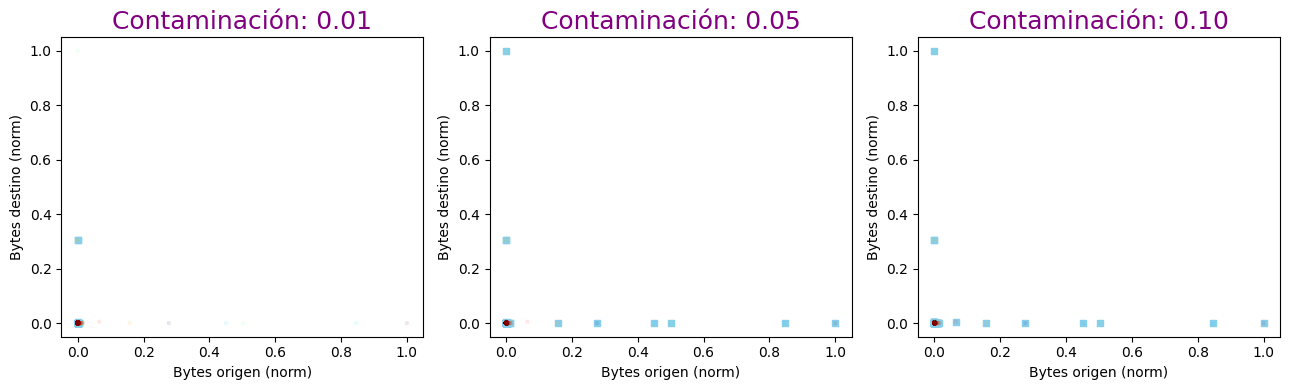

In [52]:
# Graficar datos anómalos (estilo de los apuntes del profe)
# src_bytes vs dst_bytes (bytes enviados vs recibidos)
col_x = cols_num.index('src_bytes')
col_y = cols_num.index('dst_bytes')

plt.set_cmap('jet')
fig = plt.figure(figsize=(13, 4))

for i in range(len(c)):
    ax = fig.add_subplot(1, 3, i+1)
    ax.scatter(kdd_norm[resultados[i] == -1][:, col_x],
               kdd_norm[resultados[i] == -1][:, col_y],
               c='skyblue', marker='s', s=15, label='Anómalo')
    ax.scatter(kdd_norm[:, col_x],
               kdd_norm[:, col_y],
               c=range(kdd_norm.shape[0]), marker='x',
               s=5, alpha=0.1)
    ax.set_title('Contaminación: %0.2f' % c[i], size=18, color='purple')
    ax.set_ylabel('Bytes destino (norm)', size=10)
    ax.set_xlabel('Bytes origen (norm)', size=10)

plt.tight_layout()
plt.show()

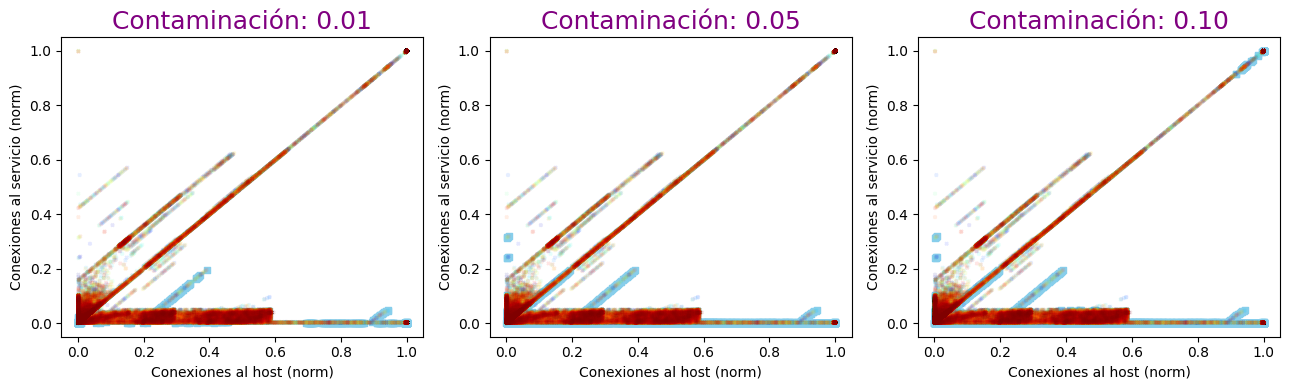

In [53]:
# Otra vista: count vs srv_count
col_x2 = cols_num.index('count')
col_y2 = cols_num.index('srv_count')

fig = plt.figure(figsize=(13, 4))

for i in range(len(c)):
    ax = fig.add_subplot(1, 3, i+1)
    ax.scatter(kdd_norm[resultados[i] == -1][:, col_x2],
               kdd_norm[resultados[i] == -1][:, col_y2],
               c='skyblue', marker='s', s=15, label='Anómalo')
    ax.scatter(kdd_norm[:, col_x2],
               kdd_norm[:, col_y2],
               c=range(kdd_norm.shape[0]), marker='x',
               s=5, alpha=0.1)
    ax.set_title('Contaminación: %0.2f' % c[i], size=18, color='purple')
    ax.set_ylabel('Conexiones al servicio (norm)', size=10)
    ax.set_xlabel('Conexiones al host (norm)', size=10)

plt.tight_layout()
plt.show()

### 4.3 Resultados

In [54]:
# Comprobamos: las anomalías detectadas, cuántas son realmente ataques?
real_class = df_kdd['is_anomaly'].values

for i in range(len(c)):
    anomalos = (resultados[i] == -1)
    ataques_en_anomalos = real_class[anomalos].sum()
    total_anom = anomalos.sum()
    print(f'Contaminación {c[i]:.0%}: {total_anom} anomalías detectadas, '
          f'de las cuales {ataques_en_anomalos} son ataques reales ({ataques_en_anomalos/total_anom*100:.1f}%)')

Contaminación 1%: 1251 anomalías detectadas, de las cuales 1050 son ataques reales (83.9%)
Contaminación 5%: 6299 anomalías detectadas, de las cuales 4978 son ataques reales (79.0%)
Contaminación 10%: 12593 anomalías detectadas, de las cuales 7763 son ataques reales (61.6%)


In [55]:
# Qué tipos de ataque detecta como anómalos?
for i in range(len(c)):
    anomalos = (resultados[i] == -1)
    print(f'\n--- Contaminación {c[i]:.0%} ---')
    print(df_kdd[anomalos]['label'].value_counts().head(8))


--- Contaminación 1% ---
label
satan        765
normal       201
ipsweep      115
teardrop      66
portsweep     62
nmap          14
land          12
neptune        6
Name: count, dtype: int64

--- Contaminación 5% ---
label
satan           2122
portsweep       1654
normal          1321
ipsweep          320
nmap             266
teardrop         249
neptune          187
guess_passwd      52
Name: count, dtype: int64

--- Contaminación 10% ---
label
normal         4830
portsweep      2487
satan          2274
neptune        1026
ipsweep         474
teardrop        352
warezclient     296
back            282
Name: count, dtype: int64


In [56]:
# Los datos anómalos con contaminación 5%
kdd_norm[resultados[1] == -1]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 2.90000000e-01, 1.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 6.20000000e-01, 1.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.00000000e+00, 6.80000000e-01],
       ...,
       [6.29253286e-04, 1.03191106e-06, 3.16961711e-06, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.00000000e+00, 9.30000000e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.00000000e+00, 1.00000000e+00]], shape=(6299, 38))

### 4.4 Conclusiones

- Con **contaminación al 1%** detecta solo las conexiones más extremas. El porcentaje de ataques reales entre las anomalías es alto (alta precisión), pero se pierden muchos ataques (baja cobertura). Es como un filtro muy fino.
- Con **5%** amplía la detección y captura más ataques. Es el mejor equilibrio entre precisión y cobertura para este dataset.
- Con **10%** detecta bastantes más anomalías pero también incluye más tráfico normal (falsos positivos). En un entorno real esto significaría más trabajo para los analistas.
- En las gráficas se ve que las anomalías (cuadrados skyblue) se concentran en conexiones con patrones de bytes inusuales: muchos bytes enviados/recibidos o muchas conexiones simultáneas.
- El Isolation Forest detecta principalmente ataques tipo **DoS** (neptune, smurf) que tienen patrones de tráfico muy distintos al normal. Los ataques más sutiles (como los de tipo probe o R2L) son más difíciles de detectar porque se parecen más al tráfico normal.
- **¿Por qué Isolation Forest para ciberseguridad?** Porque no necesita datos etiquetados para entrenar: aprende qué es "normal" y marca lo que se desvía. En la realidad, tener datos etiquetados de ataques es difícil y caro.
- Como mejora, se podría combinar con otros modelos (ej. One-Class SVM) o ajustar la contaminación según el coste de cada tipo de error (falso positivo vs falso negativo).